# Phase 5b — Baseline Forecasts

Fits seven intermittent-demand baselines for every product using two
fixed origins aligned to the global-model time split:

| Origin | Forecast target weeks | Split |
|---|---|---|
| 2025-03-24 | 2025-03-31 → 2025-06-16 | valid |
| 2025-06-16 | 2025-06-23 → 2025-09-08 | test  |

Models: **Naive · SeasonalNaive(52) · WindowAverage(12) ·
CrostonClassic · CrostonOptimized · CrostonSBA · TSB(0.3, 0.3)**

Figure 26 saved to `outputs/figures/` at 140 dpi.
Comparison metrics computed in Phase 6.

In [1]:
import sys, time
from pathlib import Path

ROOT = Path().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.baselines import build_baselines, MODEL_COLS

FIGS       = ROOT / "outputs" / "figures"
PREDS_FILE = ROOT / "data/processed/preds_baselines.parquet"
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 140,
    "figure.facecolor": "white", "axes.facecolor": "#f8f8f8",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.color": "#cccccc",
    "font.family": "sans-serif", "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 8, "legend.frameon": True, "legend.framealpha": 0.85,
})

MODEL_COLOURS = {
    "Naive":            "#888888",
    "SeasonalNaive":    "#2E86AB",
    "WindowAverage":    "#44BBA4",
    "CrostonClassic":   "#F18F01",
    "CrostonOptimized": "#E94F37",
    "CrostonSBA":       "#9B51E0",
    "TSB":              "#C73E1D",
}
MODEL_LS = {
    "Naive":            (0, (3, 2)),
    "SeasonalNaive":    "-",
    "WindowAverage":    "--",
    "CrostonClassic":   "-.",
    "CrostonOptimized": (0, (5, 1)),
    "CrostonSBA":       (0, (1, 1)),
    "TSB":              "-",
}

def savefig(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight", dpi=140)
    print(f"Saved -> {name}")


/Users/nethmini/Documents/GitHub/Cinnamon-Export-Sales-Forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Build / load baseline forecasts ─────────────────────────────────────────
if not PREDS_FILE.exists():
    print("Running build_baselines() …")
    t0 = time.time()
    preds, timings = build_baselines(
        weekly_product_path=ROOT / "data/processed/weekly_product.parquet",
        out_path=PREDS_FILE,
    )
    print(f"Total wall-clock: {timings['total']:.1f}s")
    print(f"  VALID fit+predict: {timings['valid']:.1f}s")
    print(f"  TEST  fit+predict: {timings['test']:.1f}s")
else:
    preds = pd.read_parquet(PREDS_FILE)
    preds["target_week"] = pd.to_datetime(preds["target_week"])
    print(f"Loaded {PREDS_FILE.name}  shape={preds.shape}")

print(f"\nRows by split: { {k: f'{v:,}' for k, v in preds['split'].value_counts().items()} }")
print(f"Unique products (valid): {preds[preds.split=='valid']['ProductID'].nunique():,}")
print(f"Unique products (test) : {preds[preds.split=='test' ]['ProductID'].nunique():,}")


Loaded preds_baselines.parquet  shape=(302892, 12)

Rows by split: {'test': '155,448', 'valid': '147,444'}
Unique products (valid): 12,287
Unique products (test) : 12,954


In [3]:
# ── Per-model summary (TEST period) ─────────────────────────────────────────
test_preds = preds[preds["split"] == "test"].copy()

print("=" * 65)
print("PER-MODEL SUMMARY — TEST period")
print(f"(y_true: {len(test_preds):,} rows, "
      f"{(test_preds['y_true']==0).mean()*100:.1f}% zero)")
print("=" * 65)
print(f"  {'Model':<20}  {'Mean forecast':>14}  {'% zero fcst':>12}  {'Max fcst':>10}")
print(f"  {'-'*20}  {'-'*14}  {'-'*12}  {'-'*10}")
for m in MODEL_COLS:
    col = test_preds[m]
    print(f"  {m:<20}  {col.mean():>14.3f}  {(col==0).mean()*100:>11.1f}%  {col.max():>10.1f}")
print("=" * 65)
print(f"  y_true mean (TEST): {test_preds['y_true'].mean():.3f}")


PER-MODEL SUMMARY — TEST period
(y_true: 155,448 rows, 98.1% zero)
  Model                  Mean forecast   % zero fcst    Max fcst
  --------------------  --------------  ------------  ----------
  Naive                          5.126         96.0%     11254.0
  SeasonalNaive                  8.374         95.8%     21671.0
  WindowAverage                  4.581         82.9%      2633.8
  CrostonClassic                42.580          0.0%     18844.2
  CrostonOptimized              38.222          0.0%     12974.8
  CrostonSBA                    40.451          0.0%     17902.0
  TSB                            5.961          0.0%      2590.4
  y_true mean (TEST): 5.076


In [4]:
# ── Pick example products: one A, one B, one sparse-C ────────────────────────
seg  = pd.read_parquet(ROOT / "data/processed/product_segments.parquet")
wp   = pd.read_parquet(ROOT / "data/processed/weekly_product.parquet")
wp["week_start"] = pd.to_datetime(wp["week_start"])

# A-class: top volume, has test-period forecasts, some non-zero history
test_pids = set(test_preds["ProductID"].unique())
a_cands = (seg[(seg["abc_class"]=="A") & seg["ProductID"].isin(test_pids)]
           .sort_values("total_qty", ascending=False))
# Pick one with reasonably visible demand pattern (active weeks > 40)
pick_A = a_cands[a_cands["n_active_weeks"] > 40]["ProductID"].iloc[5]

# B-class: medium volume
b_cands = (seg[(seg["abc_class"]=="B") & seg["ProductID"].isin(test_pids)]
           .sort_values("total_qty", ascending=False))
pick_B = b_cands[b_cands["n_active_weeks"].between(5, 30)]["ProductID"].iloc[3]

# Sparse C: very few active weeks (intermittent tail)
c_cands = (seg[(seg["abc_class"]=="C") & seg["ProductID"].isin(test_pids) &
               (seg["demand_class"].isin(["Intermittent","Lumpy"]))]
           .sort_values("n_active_weeks"))
pick_C = c_cands[c_cands["n_active_weeks"].between(3, 10)]["ProductID"].iloc[2]

examples = {
    f"ABC-A  {pick_A}": pick_A,
    f"ABC-B  {pick_B}": pick_B,
    f"Sparse-C  {pick_C}": pick_C,
}
print("Example products chosen:")
for label, pid in examples.items():
    row = seg[seg["ProductID"]==pid].iloc[0]
    print(f"  {label}: abc={row['abc_class']} demand={row['demand_class']} "
          f"active_wks={row['n_active_weeks']} total_qty={row['total_qty']:.0f}")


Example products chosen:
  ABC-A  20494-036: abc=A demand=Intermittent active_wks=65 total_qty=192290
  ABC-B  97139-073: abc=B demand=Intermittent active_wks=9 total_qty=2682
  Sparse-C  26958-075: abc=C demand=Intermittent active_wks=3 total_qty=148


Saved -> 26_baseline_example_forecasts.png


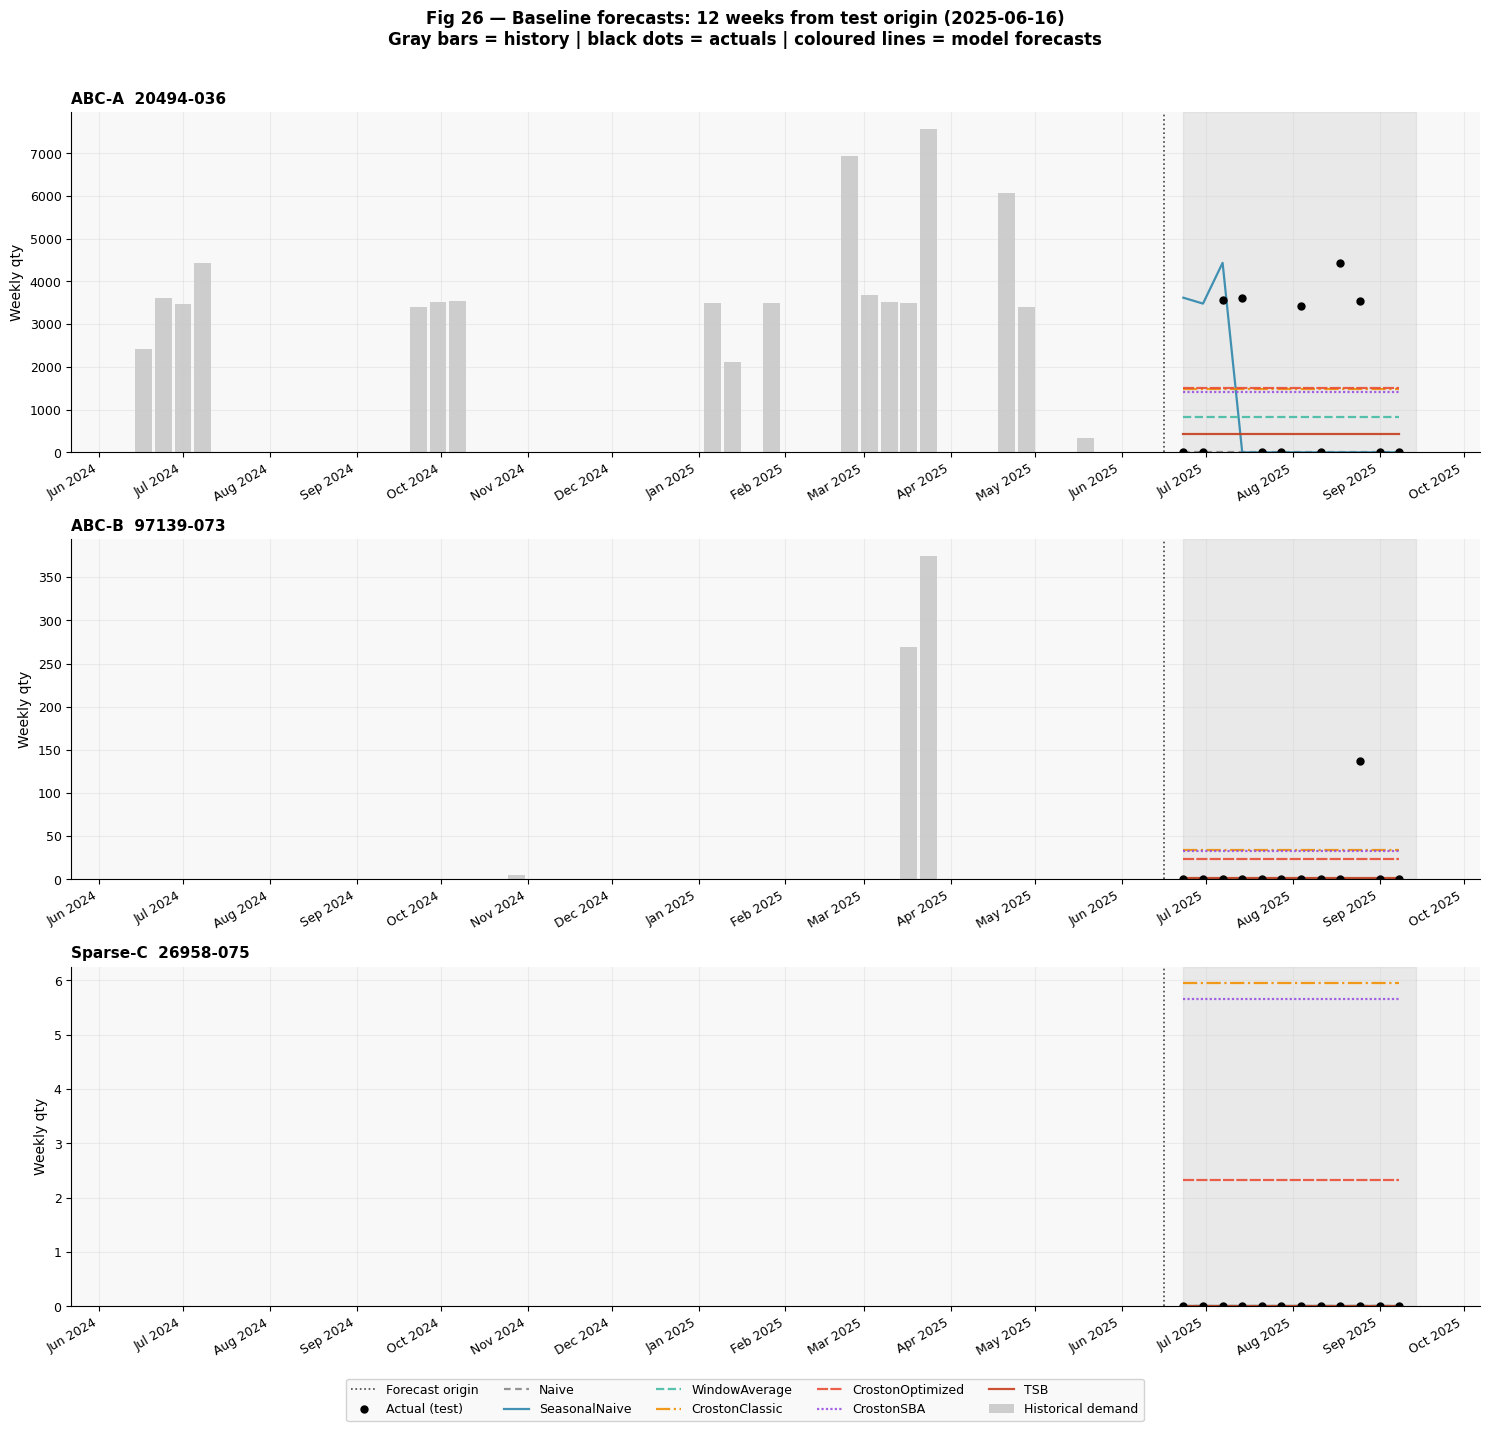

In [5]:
# ── Fig 26 — Example products: history + 12-week baseline forecasts ──────────
TEST_ORIGIN  = pd.Timestamp("2025-06-16")
HIST_WEEKS   = 52   # weeks of history to show before forecast origin

fig, axes = plt.subplots(len(examples), 1, figsize=(15, 4.5 * len(examples)))

for ax, (label, pid) in zip(axes, examples.items()):
    # Full history for this product
    hist_all = wp[wp["ProductID"] == pid].sort_values("week_start")

    # Show last HIST_WEEKS before the test origin
    show_start = TEST_ORIGIN - pd.Timedelta(weeks=HIST_WEEKS)
    hist_show  = hist_all[
        (hist_all["week_start"] >= show_start) &
        (hist_all["week_start"] <= TEST_ORIGIN)
    ]

    # Test-period actuals and forecasts from preds_baselines
    fcast = test_preds[test_preds["ProductID"] == pid].sort_values("target_week")

    # ── Plot history as bar chart ─────────────────────────────────────────────
    ax.bar(hist_show["week_start"], hist_show["qty"],
           width=6, color="#BBBBBB", alpha=0.7, label="Historical demand")

    # ── Shaded forecast region ────────────────────────────────────────────────
    fc_start = fcast["target_week"].min()
    fc_end   = fcast["target_week"].max()
    ax.axvspan(fc_start, fc_end + pd.Timedelta(days=6),
               alpha=0.08, color="#444444", zorder=0)
    ax.axvline(TEST_ORIGIN, color="#444444", linewidth=1.2,
               linestyle=":", label="Forecast origin")

    # ── Actual demand in test period (black dots) ─────────────────────────────
    ax.plot(fcast["target_week"], fcast["y_true"],
            "ko", markersize=5, zorder=5, label="Actual (test)", linewidth=0)

    # ── Baseline forecasts (one line per model) ───────────────────────────────
    for model in MODEL_COLS:
        ax.plot(fcast["target_week"], fcast[model],
                color=MODEL_COLOURS[model], linestyle=MODEL_LS[model],
                linewidth=1.6, label=model, alpha=0.9)

    ax.set_title(label, loc="left")
    ax.set_ylabel("Weekly qty")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# Shared legend under the last axis
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.04), fontsize=9)
fig.suptitle(
    "Fig 26 — Baseline forecasts: 12 weeks from test origin (2025-06-16)\n"
    "Gray bars = history | black dots = actuals | coloured lines = model forecasts",
    fontweight="bold", y=1.01,
)
plt.tight_layout()
savefig(fig, "26_baseline_example_forecasts.png")
plt.show()


In [6]:
print("\nPhase 5b artefacts:")
print(f"  {PREDS_FILE}  ({PREDS_FILE.stat().st_size // 1024:,} KB)")
print()
print("Phase 5b figures saved:")
for f in sorted(p for p in FIGS.iterdir()
                if p.suffix == ".png" and int(p.stem[:2]) == 26):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")



Phase 5b artefacts:
  /Users/nethmini/Documents/GitHub/Cinnamon-Export-Sales-Forecasting/data/processed/preds_baselines.parquet  (738 KB)

Phase 5b figures saved:
  26_baseline_example_forecasts.png  (209 KB)
